# Frontend-Architektur: Routing, MVP und ViewModels

## Routing in `flet`

```python
import flet as ft

def main(page: ft.Page):
    page.title = "Hallo Flet!"
    page.add(ft.Text("Willkommen bei Flet im Browser!"))

ft.run(main, view=ft.AppView.WEB_BROWSER, port=8080)
```

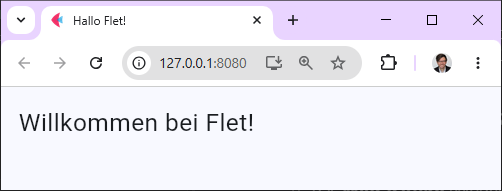

### Flet im Browser

```python
ft.run(main, view=ft.AppView.WEB_BROWSER, port=8080)
```

- `view=ft.AppView.WEB_BROWSER` startet die App im Browser.
- `port=8080` legt den Port fest, auf dem die App erreichbar ist (z.B. `http://localhost:8080`).
- **Tipp**: Beenden Sie Ihre App mit `CTRL+C` im Terminal, damit der Port wieder freigegeben wird.

💡 **Vorteil:** Wir sehen jetzt die URL und können sie für das Routing verwenden.

👉 **Achtung:** Das Routing funktionert später auch in der nativen App, im Browser können wir aber **besser debuggen**. 

### Eine App mit zwei Seiten

```python
class BobView(ft.Column):

    def __init__(self):
        super().__init__()
        self.controls.append(ft.Text("Spongebob"))


class KevinView(ft.Column):

    def __init__(self):
        super().__init__()
        self.controls.append(ft.Text("Kevin Seegurke"))
```

❓ **Frage:** Wie können wir wahlweise die eine oder die andere Seite anzeigen?

### Routing mit `page.route`

```python
class FletNavigator:
    page: ft.Page

    def __init__(self, page: ft.Page):
        self.page = page
        page.on_route_change = self.on_route_change

    def on_route_change(self):
        self.page.clean()
        if self.page.route == "/bob":
            self.page.add(BobView())
        elif self.page.route == "/kevin":
            self.page.add(KevinView())
```

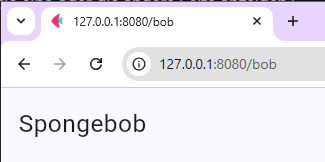

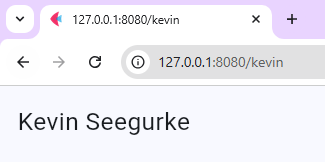

### Routing mit `page.route` -- Erklärung 1/2

```python
class FletNavigator:
    page: ft.Page

    def __init__(self, page: ft.Page):
        self.page = page
        page.on_route_change = self.on_route_change
```

- Die Klasse `FletNavigator` dient dazu, eine Referenz auf die `page` zu speichern.
  - Im Gegensatz zu Controls wie `ft.Button`, `ft.TextField`, wird die Page nicht im Konstruktor erstellt, sondern als Parameter übergeben.
- Wir setzen den Event-Handler `on_route_change` um auf Änderungen der URL zu reagieren.

### Routing mit `page.route` -- Erklärung 2/2

```python
    def on_route_change(self):
        self.page.clean()
        if self.page.route == "/bob":
            self.page.add(BobView())
        elif self.page.route == "/kevin":
            self.page.add(KevinView())
```

- `self.page.clean()` entfernt alle Controls von der Seite.
- `self.page.route` enthält die aktuelle URL-Route (z.B. `/bob` oder `/kevin`).
- Wir fügen der Page jeweils die passende View hinzu.

### Anpassen der Startseite

```python
class FletNavigator:
    page: ft.Page

    def __init__(self, page: ft.Page):
        self.page = page
        page.on_route_change = self.on_route_change
        page.go("/bob")
```

❓ Was verändert die Zeile `page.go("/bob")`? 

👉 Damit setzen wir die Startseite auf `/bob`. (Die Methode `page.go()` verändert die URL und löst das Event `RouteChange` aus.)

### Navigation zwischen Seiten

```python
class BobView(ft.Column):

    def __init__(self):
        super().__init__()
        self.controls.append(ft.Text("Spongebob"))
        self.controls.append(ft.Button("Kevin", on_click=self.on_button_click))

    def on_button_click(self, e: ft.Event[ft.Button]):
        if isinstance(self.page, ft.Page):
            self.page.go("/kevin")
```

- Wir schreiben einen gewöhnlichen Event-Handler für den Button.
- `if isinstance(self.page, ft.Page)` ist ein kleiner Trick, weil der Type Checker nicht weiß, dass `self.page` tatsächlich eine `ft.Page` ist. -- Dieses `if` wird immer erfüllt sein!
- `self.page.go("/kevin")` verändert die URL und löst das Event `RouteChange` aus.

## Einführung: Patterns in der Softwareentwicklung

### Was ist ein Pattern?

- Wir können jetzt objektorientiert modellieren: 
  - Objekte aus der Wirklichkeit (z.B. Person, Film),
  - Objekte aus der Phantasie (z.B. Raumschiff, Heiltrank),
  - Objekte aus der Software (z.B. UI-Dialoge, `FileWriter`).
- Erfahrungswert: Nicht jede Modellierung, die fachlich plausibel ist, funktioniert auch gut.
- **Patterns**: Erprobte Lösungen für häufig auftretende Probleme in der Softwareentwicklung.

👉 Eine bekanntermaßen *schlechte* Lösung bezeichnet man auch als **Anti-Pattern**.

### Patterns in dieser Veranstaltung

- Wir lernen heute zwei Patterns kennen:
  - das **MVP-Pattern** (Model-View-Presenter) für die Architektur von Frontends und
  - das **Immutable-Interface-Pattern** um den Zugriff auf das Datenmodell zu steuern.
- In einer späteren Vorlesung lernen wir noch das **Repository-Pattern** kennen, mit dem wir den Zugriff auf Datenquellen kapseln können.

## Das MVP-Pattern

### Anti-Pattern: Monolithische Frontends

- Als monolithisches Frontend bezeichnet man ein Frontend, bei der die gesamte Logik in einer einzigen UI-Klasse  implementiert ist.
- **Wesentliche Probleme:**
  1. Übersicht,
  2. Testbarkeit,
  3. Wartbarkeit

1. **Übersicht:** 
  - Wenn aller UI-Code in einer Klasse ist, sieht man schnell den Wald vor lauter Bäumen nicht mehr.
  - Eine Aufteilung in mehrere Klassen ermöglicht es, Coding-Richtlinien zu etablieren (z.B. ein Event-Handler darf grundsätzlich nicht XY tun).

2. **Testbarkeit:** 
  - UI-Komponenten sind wesentlich schlechter testbar als Klassen ohne direkten Bezug zu einem UI-Framework.
  - Wir möchten möglichst viel Logik in Klassen, die `flet` gar nicht kennen.

3. **Wartbarkeit:**
  - Alle Logik in einer Klasse macht es schwer, die Folgen einer kleinen Änderung abzuschätzen.
  - Eine Aufteilung in mehrere Klassen begrenzt die Auswirkungen von Änderungen.

### Hauptziele der Aufteilung

1. `flet`-Code von Nicht-`flet`-Code trennen
    - Nicht-`flet`-Code wird testbar.
    - `flet` wird austauschbar (z.B. durch ein anderes UI-Framework).
  
2. Die UI sollte unsere Daten nur über definierte Schnittstellen verändern können. 
   - Wir verhindern unbeabsichtigte Seiteneffekte.
   - Wir wissen genau, an welchen Stellen Daten verändert werden können.

### Das MVP-Pattern

- Steht für Model-View-Presenter.
- Wir teilen jede Seite in drei Klassen auf:
  - **Model**: Enthält die Datenobjekte mit der fachlichen Logik.
  - **View**: In `flet` programmiert, enthält alle UI-Elemente, kennt das Model **nicht**.
  - **Presenter**: Vermittelt zwischen View und Model. Kennt `flet` nicht, aber das Model. Stellt dem View  **unveränderliche Daten** und **Schnittstellen zur Veränderung** (=Methoden) zur Verfügung. 

## MVP am Beispiel: Der Temperaturrechner

### Schritt 1: Das Model

- Wir zeigen jeweils eine korrespondierende Celsius- und Fahrenheit-Temperatur an.
- Welches Prinzip der Software-Entwicklung verletzt die folgende Klasse?

```python
@dataclass
class TemperaturModel:
    _celsius: float
    _fahrenheit: float
```

- Wie könnten wir das SPOT-Prinzip (Single Point of Truth) einhalten?

```python
@dataclass
class TemperaturModel:
    _kelvin: float = 0.0

    @property
    def fahrenheit(self) -> float:
        return (self.celsius * 9/5) + 32

    @property
    def celsius(self) -> float:
        return self._kelvin - 273.15

    def set_celsius(self, celsius: float):
        self._kelvin = celsius + 273.15

    def set_fahrenheit(self, fahrenheit: float):
        self._kelvin = (fahrenheit - 32) * 5/9 + 273.15
```

### Test des `TemperaturModel`

```python
model = TemperaturModel()
model.set_celsius(100)
print(model.celsius) # Ausgabe: 100.0
print(model.fahrenheit) # Ausgabe: 212.0

model.set_fahrenheit(100)
print(model.celsius) # Ausgabe: 37.77777777777778
print(model.fahrenheit) # Ausgabe: 100.0
```

💡 Die fachliche Logik existiert hier völlig ohne ein User-Interface.

### Schritt 2: Der Presenter (ohne Interaktion)

- Unser UI soll drei Umrechnungs-Paare anzeigen -- jeweils Celsius und Fahrenheit.
- Wir benötigen also drei (geschützte) Instanzen des `TemperaturModel`.
- Eine öffentliche Methode `temperaturen()` gibt die *reinen* Daten zurück.
  

```python
class TempCalcPresenter(ft.Row):

    _temperatur_modelle: list[TemperaturModel]

    def __init__(self):
        super().__init__()
        self._temperatur_modelle = [TemperaturModel(), TemperaturModel(), TemperaturModel()]

    def temperaturen(self) -> list[tuple[float, float]]:
        temperaturen: list[tuple[float, float]] = []
        for modell in self._temperatur_modelle:
            temperaturen.append((modell.celsius, modell.fahrenheit))
        return temperaturen
```

### Schritt 3: Die View (ohne Interaktion)

- Die View-Klasse ist ein `flet`-Dialog, der den Presenter "kennt".
- Der Presenter wird im Konstruktor übergeben.
- Die View holt die Daten vom Presenter und zeigt sie an.

```python
class TempCalcView(ft.Column):
    presenter: TempCalcPresenter

    def __init__(self, presenter: TempCalcPresenter):
        super().__init__()
        self.presenter = presenter
        self._build_ui()

    def _build_ui(self):
        self.controls.clear()
        for i, temp_c, temp_f in self.presenter.temperaturen():
            input_c = ft.TextField(label="°C", value=f"{temp_c:.2f}")
            input_f = ft.TextField(label="°F", value=f"{temp_f:.2f}")
            self.controls.append(ft.Row([input_c, input_f]))
```

### Presenter mit Schnittstelle zur Interaktion

- Es soll nun möglich sein, jeden der drei Celsiuswerte zu verändern.
- Es gibt nur einen Presenter, aber drei `TemperaturModel`-Instanzen. Wie muss die richtige Instanzmethode aussehen?

```python
class TempCalcPresenter(ft.Row):
    ...

    def setze_celsius(self, index: int, celsius: float):
        print(f"Setze Wert {index} auf {celsius}°C")
        self._modelle[index].set_celsius(celsius)
```

👉 Die Methode braucht **zwei** Parameter: Welcher Wert soll verändert werden? Wie lautet der neue Wert?

❓ Woher weiß der View, welcher Index verändert werden soll?

### Die Methode `temperaturen()` mit Indizes

- Wir müssen mit den Daten auch den jeweiligen Index zurückgeben.

```python
class TempCalcPresenter(ft.Row):
    ...

    def temperaturen(self) -> list[tuple[int, float, float]]:
        temperaturen: list[tuple[int, float, float]] = []
        for i in range(len(self._temperatur_modelle)):
            modell = self._temperatur_modelle[i]
            temperaturen.append((i, modell.celsius, modell.fahrenheit))
        return temperaturen
```

### Der interaktive View

```python
    def _build_ui(self):
        self.controls.clear()
        for i, temp_c, temp_f in self.presenter.temperaturen():
            input_c = ft.TextField(label="°C", value=f"{temp_c:.2f}")
            input_f = ft.TextField(label="°F", value=f"{temp_f:.2f}")
            self.controls.append(ft.Row([input_c, input_f]))

            # Neu: Setze Attribut data (Index des Modells) und Event-Handler
            input_c.data = i
            input_c.on_blur = self._on_celsius_changed
```

### Event-Handler für die Änderung der Celsius-Temperatur

```python
    def _on_celsius_changed(self, e):
        index = e.control.data
        celsius = float(e.control.value)
        self.presenter.update_temperature(index, celsius)
        self._build_ui() # baue UI neu auf
``` 

### Hinweise

- Wir bauen hier nach jeder Änderung die gesamte UI neu auf.
  - Nicht allzu effizient, aber einfach und sauber.

👉 **Faustregel:** Suchen Sie zunächst immer die *einfachste* Lösung. Lösen Sie Performance-Probleme erst dann, wenn sie auftreten.

- Wir verwenden hier den (Listen-)Index als ID. Im Ernstfall ist eine echte, eindeutige ID (z.B. aus der Datenbank) besser.


## View Models

`TempCalcPresenter.temperaturen()` gibt derzeit eine Liste von Tupeln zurück. Das ist hässlich un unflexibel.

```python
class TempCalcPresenter(ft.Row):
    ...

    def temperaturen(self) -> list[tuple[int, float, float]]:
        ...
```

❓ **Fragen:** 
1. Warum tun wir das überhaupt und geben nicht einfach `TemperaturModel`-Instanzen zurück?
2. Gibt es einen Vorteil? 
3. Könnten wir den Vorteil auch anders erreichen?

### View Model als Tupel

`TempCalcPresenter.temperaturen()` gibt derzeit eine Liste von Tupeln zurück. Das ist hässlich und unflexibel.

```python
class TempCalcPresenter(ft.Row):
    ...

    def temperaturen(self) -> list[tuple[int, float, float]]:
        ...
```

- Tupel sind unveränderlich, d.h. die View *kann* die Daten nicht verändern.
- Wir können also sicher sein, dass die Daten nur über `presenter.setze_celsius()` verändert werden.
  - Das bringt Übersicht und beseitigt Fehlerquellen.

❓ Ist das die beste Lösung?

### Unveränderliche View Models

- Bessere Lösung: Eine unveränderliche View-Model-Klasse.

```python
@dataclass(frozen=True)
class TemperaturViewModel:
    index: int
    celsius: float
    fahrenheit: float
```

### Die Methode `temperaturen()` mit ViewModels

```python
class TempCalcPresenter(ft.Row):
    ...

    def temperaturen(self) -> list[TemperaturViewModel]:
        temperaturen: list[TemperaturViewModel] = []
        for i in range(len(self._temperatur_modelle)):
            modell = self._temperatur_modelle[i]
            view_model = TemperaturViewModel(i, modell.celsius, modell.fahrenheit)
            temperaturen.append(view_model)
        return temperaturen
```

### Zu viele Klassen?

- In der modernen Software-Entwicklung ist es völlig normal, dass mehrere Datenmodelle nebeneinander existieren.
- Das ist kein Problem, sondern eine Stärke der objektorientierten Programmierung.

👉 Haben Sie keine Angst vor zu vielen Klassen!

## Vorgehensmodell für das MVP-Pattern

<h3 id="schritt-1-das-model">Schritt 1: Das Model</h3>
<ul>
<li>Bilden Sie alle <strong>Daten</strong> und die <strong>fachliche Logik</strong> Ihrer Domäne in <em>Dataclasses</em> ab.</li>
</ul>
<p>❓ Was gehört ins Model?</p>
<table>
<thead>
<tr>
<th></th>
<th>ins Model?</th>
</tr>
</thead>
<tbody>
<tr>
<td>Gehört es zur Domänenbeschreibung?</td>
<td>✅</td>
</tr>
<tr>
<td>Würden wir es benötigen, wenn wir kein UI hätten (sondern nur ein Kommandozeilen-Skript)?</td>
<td>✅</td>
</tr>
<tr>
<td>Wird es von mehr als einem View benötigt?</td>
<td>✅</td>
</tr>
<tr>
<td>Wird es nur für die Darstellung benötigt?</td>
<td>❌</td>
</tr>
</tbody>
</table>


<h3 id="schritt-2-der-presenter">Schritt 2: Der Presenter</h3>
<ul>
<li>Bilden Sie alle Anteile der <strong>UI</strong> für die Sie nicht das UI-Framework (also: `flet`) benötigen, im <em>Presenter</em> ab:</li>
<ul>
    <li>Alle dargestellten Daten als <strong>unveränderliche Objekte</strong></li>
    <li>Alle Operationen auf den Daten als <strong>öffentliche Methoden</strong></li>
</ul>
</ul>
<p>❓ Was gehört in den Presenter?</p>
<table>
<thead>
<tr>
<th></th>
<th>in den Presenter?</th>
</tr>
</thead>
<tbody>
<tr>
<td>Würden wir es benötigen, wenn wir kein UI hätten (sondern nur ein Kommandozeilen-Skript)?</td>
<td>❌</td>
</tr>
<tr>
<td>Wird es von mehr als einem Dialog benötigt?</td>
<td>❌</td>
</tr>
<tr>
<td>Benötigt es <code>flet</code> (oder ein anderes UI-Framework)?</td>
<td>❌</td>
</tr>
<tr>
<td>Gehört es genau zu diesem Dialog und benötigt nicht das UI-Framework?</td>
<td>✅</td>
</tr>
</tbody>
</table>


<h3 id="schritt-3-der-view">Schritt 3: Der/die View</h3>
<ul>
<li>Bilden Sie hier alle Anteile der <strong>UI</strong> ab, für die Sie unbedingt das UI-Framework benötigen.</li>
<ul>
    <ul>Widgets = Kontrollelemente</ul>
    <ul>direkt gebundene Event-Handler</ul>
</ul>
</ul>
<p>❓ Was gehört in die View?</p>
<table>
<thead>
<tr>
<th></th>
<th>in die View?</th>
</tr>
</thead>
<tbody>
<tr>
<td>Könne man es auch im Presenter abbilden (weil das Framework nicht benötigt wird)?</td>
<td>❌</td>
</tr>
<tr>
<td>Ist dies der einzige Ort, an dem es liegen kann?</td>
<td>✅</td>
</tr>
</tbody>
</table>


### Schritt 1: Das Model

- Bilden Sie alle **Daten** und die **fachliche Logik** Ihrer Domäne in _Dataclasses_ ab.

❓ Was gehört ins Model?

|                                                                                           | ins Model? |
| ----------------------------------------------------------------------------------------- | ---------- |
| Gehört es zur Domänenbeschreibung?                                                        | ✅         |
| Würden wir es benötigen, wenn wir kein UI hätten (sondern nur ein Kommandozeilen-Skript)? | ✅         |
| Wird es von mehr als einem View benötigt?                                                 | ✅         |
| Wird es nur für die Darstellung benötigt?                                                 | ❌         |

### Schritt 1: Das Model

- Bilden Sie alle **Daten** und die **fachliche Logik** Ihrer Domäne in _Dataclasses_ ab.

❓ Was gehört ins Model?

|                                                                                           | ins Model? |
| ----------------------------------------------------------------------------------------- | ---------- |
| Gehört es zur Domänenbeschreibung?                                                        | ✅         |
| Würden wir es benötigen, wenn wir kein UI hätten (sondern nur ein Kommandozeilen-Skript)? | ✅         |
| Wird es von mehr als einem View benötigt?                                                 | ✅         |
| Wird es nur für die Darstellung benötigt?                                                 | ❌         |